In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import moocore

In [28]:
df_memory_modelsize = pd.read_csv("model_sizes.csv")
df_memory_esp = pd.read_csv("../memory_results.csv")
df_memory_esp = df_memory_esp[df_memory_esp["seed"] == 888]
df_memory_esp.drop_duplicates(inplace=True)
df_memory_modelsize = df_memory_modelsize[df_memory_modelsize["seed"] == 888]
df_memory_modelsize.drop_duplicates(inplace=True)
df_accuracy = pd.read_csv("result.csv")
df_accuracy = df_accuracy[df_accuracy["seed"] == 888]
df_accuracy.drop_duplicates(inplace=True)
df_accuracy = df_accuracy[df_accuracy["dataset"] == "cifar10"]
df_hwnas = pd.read_csv("../all_hwnas.csv", index_col=0)
df_hwnas = df_hwnas[df_hwnas["seed"] == 888]
df_hwnas = df_hwnas[df_hwnas["dataset"] == "cifar10"]
df_hwnas.drop_duplicates(inplace=True)
print(f"Current status of df accuracy {len(df_accuracy)}, df_memory_modelsize {len(df_memory_modelsize)}, df_memory_esp {len(df_memory_esp)}, df_hwnas {len(df_hwnas)}")
print(f"Missing df accuracy {15625-len(df_accuracy)}, df_memory_modelsize {15625-len(df_memory_modelsize)}, df_memory_esp {15625-len(df_memory_esp)}, df_hwnas {15625-len(df_hwnas)}")


Current status of df accuracy 15572, df_memory_modelsize 12554, df_memory_esp 14704, df_hwnas 15625
Missing df accuracy 53, df_memory_modelsize 3071, df_memory_esp 921, df_hwnas 0


In [30]:
df_mergeaccandmem = df_accuracy.merge(df_memory)
df_mergeaccandmem.to_csv("../results/memandacc.csv", index=False)
df_merged = df_mergeaccandmem.merge(df_hwnas, left_on = ["seed", "idx", "dataset"], right_on = ["seed", "arch_index", "dataset"])
df_merged.to_csv("../results/alldata.csv", index=False)
print(f"When partially merged missing df_mergeaccandmem {15625-len(df_mergeaccandmem)}")
print(f"When merged missing {15625-len(df_merged)}")

When partially merged missing df_mergeaccandmem 3071
When merged missing 3071


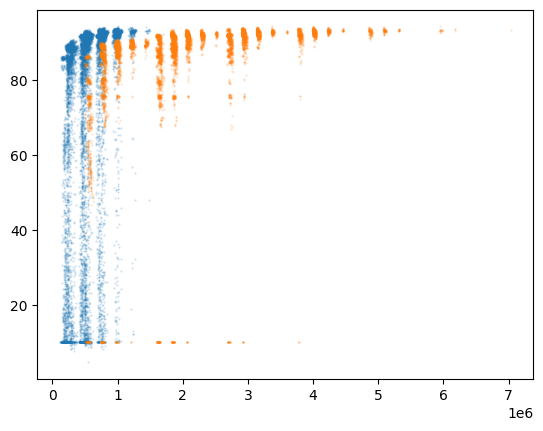

In [31]:
plt.scatter(df_merged["espdl_size_bytes"], df_merged["accuracy_esp"], alpha = 0.2, s=0.3)
plt.scatter(df_merged["torch_size_bytes"], df_merged["accuracy_fp32"], alpha = 0.2, s=0.3)
plt.savefig("sizevsacc.png")
plt.show()